In [33]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

from tqdm.notebook import tqdm
# !pip install ipywidgets

In [34]:
import acsmuthi.utility.mathematics as mths
from acsmuthi.linear_system.coupling.substrate_coupling_matrix import substrate_coupling_block_integrate, substrate_coupling_element, substrate_coupling_block
from acsmuthi.linear_system.coupling.coupling_basics import k_contour
from acsmuthi.medium import FluidMedium, ElasticMedium, RigidBoundary, MediumSystem

## rigid substrate

In [35]:
rho_fluid, c_fluid = 1.225, 331

fluid = FluidMedium(density=rho_fluid, sound_speed_longitudinal=c_fluid)
substrate = RigidBoundary() 
med = MediumSystem([fluid, substrate])

### numerical parameters variation

In [36]:
k = 1
distance = 1 / k
height = 1 / k

receiver_pos = np.array([distance/2, 0., height])
emitter_pos = np.array([-distance/2, 0., height])

In [37]:
n_max = 3

#### kmax vs step

In [38]:
true_block = substrate_coupling_block(
    emitter_pos=emitter_pos, receiver_pos=receiver_pos,
    k=k, order=n_max 
)

In [39]:
im_def = 1e-2

steps = np.geomspace(1e-1, 1e-4, 25)
finishes = np.array([1, 3, 5, 10, 40, 100])
computed_values = np.zeros((finishes.shape[0], steps.shape[0], *true_block.shape), dtype=complex)

# for i, fin in enumerate(tqdm(finishes)):
    
#     for j, stp in enumerate(steps):

#         k_par = k_contour(
#             imag_deflection=im_def, 
#             step=stp, 
#             finish=fin, 
#         ) * k
        
#         k_z = np.emath.sqrt(k ** 2 - k_par ** 2)
#         legs = mths.legendres_table(k_z / k, n_max=n_max)

#         coupling_block = substrate_coupling_block_integrate(
#             receiver_pos=receiver_pos, 
#             emitter_pos=emitter_pos,
#             k=k, order=n_max, 
#             k_parallel=k_par,
#             legendres=legs,
#             medium=med
#         )
        
#         computed_values[i, j] = coupling_block.copy()
# np.save('.\\tables\\integration\\cutoff_step_vals', computed_values)

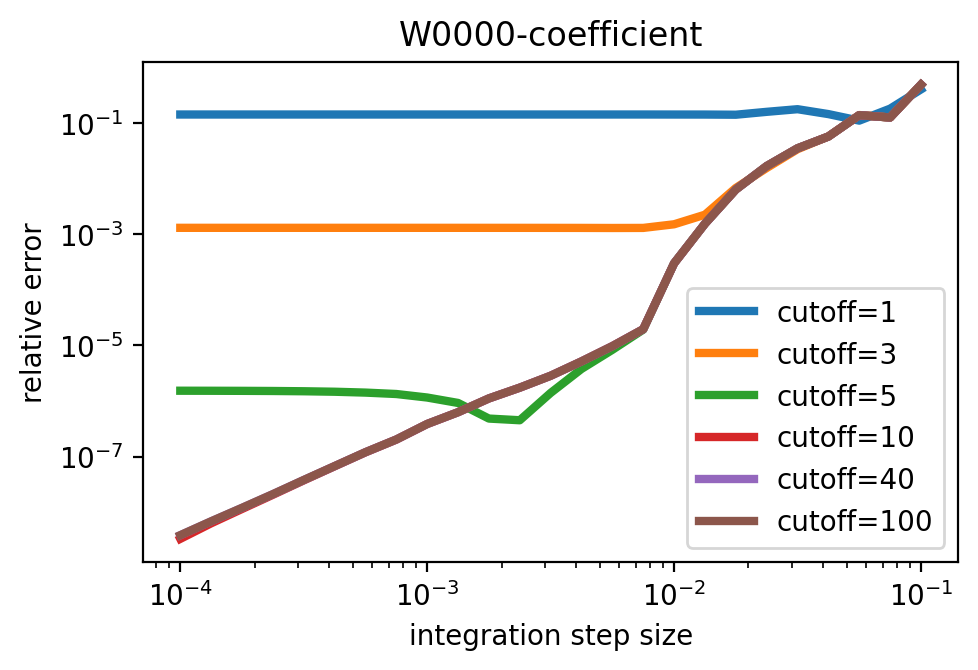

In [40]:
computed_values = np.load('testing_examples\\tables\\integration\\cutoff_step_vals.npy')

n1, m1, n2, m2 = 0, 0, 0, 0
el_idx = n1**2 + n1 + m1, n2**2 + n2 + m2

fig, ax = plt.subplots(figsize=(5, 3.5))

for i, fin in enumerate(finishes):
    val = computed_values[i, :, *el_idx]
    val0 = true_block[*el_idx]
    err = np.abs((val - val0) / val0)
    ax.loglog(steps, err, linewidth=3, label=f'cutoff={fin:.0f}')

ax.set(xlabel="integration step size", ylabel="relative error", title=f'W{m1}{n1}{m2}{n2}-coefficient')
plt.legend(), plt.tight_layout()
plt.show()


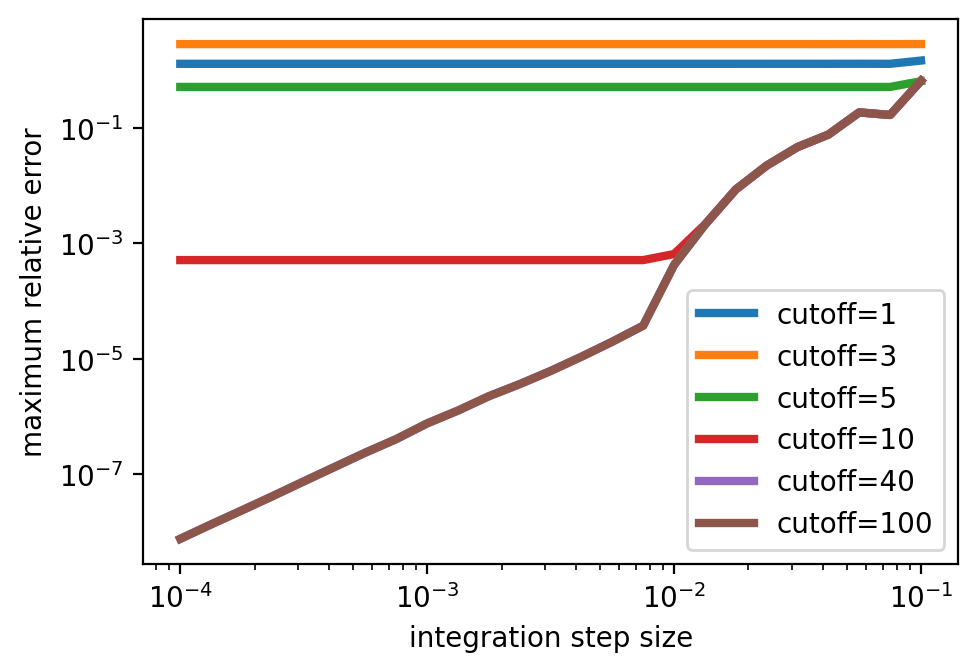

In [41]:
fig, ax = plt.subplots(figsize=(5, 3.5))

val0 = true_block
for i, fin in enumerate(finishes):
    val = computed_values[i, :]
    err = np.abs((val - val0) / val0)
    ax.loglog(steps, np.max(err, axis=(-1, -2)), linewidth=3, label=f'cutoff={fin:.0f}')

ax.set(xlabel="integration step size", ylabel="maximum relative error")
plt.legend(), plt.tight_layout()
plt.show()


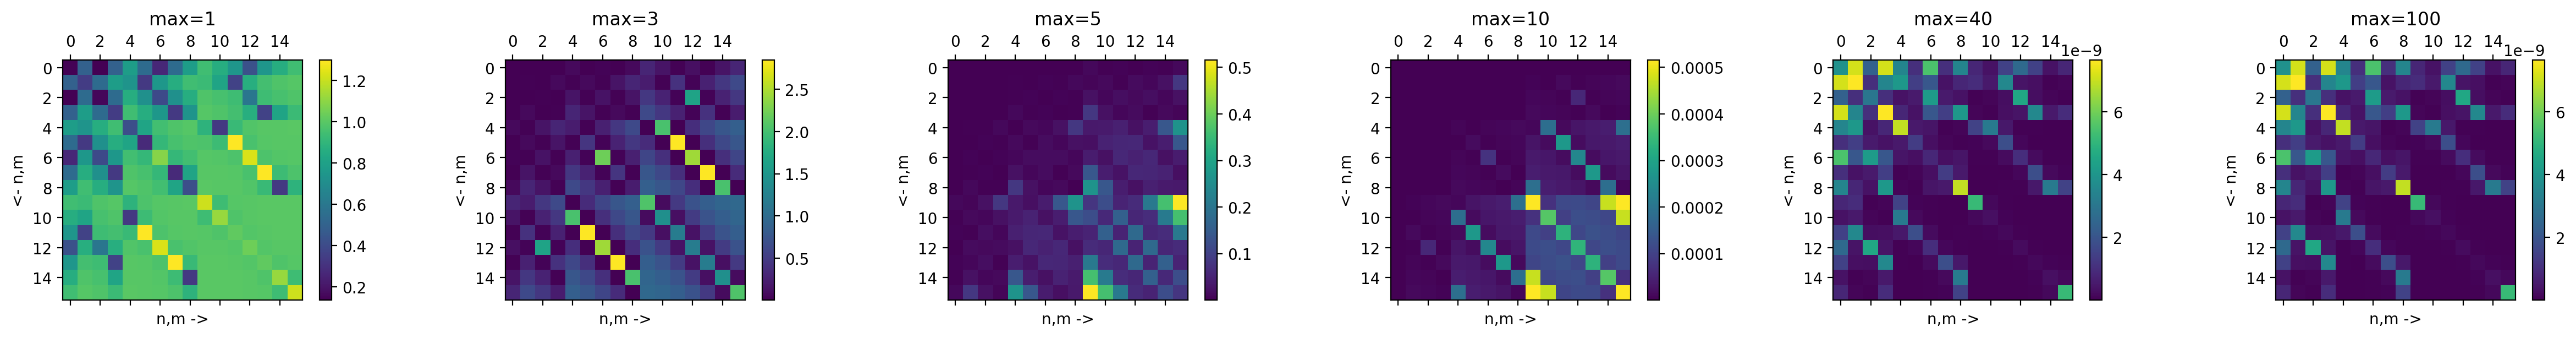

In [42]:
fig, ax = plt.subplots(1, len(finishes), figsize=(4*len(finishes), 3))

val0 = true_block
for i, fin in enumerate(finishes):
    val = computed_values[i, -1]
    err = np.abs((val - val0) / val0)
    im = ax[i].matshow(err)
    plt.colorbar(im, ax=ax[i])
    ax[i].set(ylabel='<- n,m', xlabel='n,m ->', title=f'max={fin:.0f}')
plt.tight_layout()

#### deflection vs step

In [43]:
true_block = substrate_coupling_block(
    emitter_pos=emitter_pos, receiver_pos=receiver_pos,
    k=k, order=n_max 
)

In [44]:
finish = 40

steps = np.geomspace(1e-1, 1e-4, 25)
deflecs = np.array([1e-3, 5e-3, 1e-2, 5e-2, 1e-1])

# computed_values = np.zeros((deflecs.shape[0], steps.shape[0], *true_block.shape), dtype=complex)
# for i, defl in enumerate(tqdm(deflecs)):
    
#     for j, stp in enumerate(steps):
        
#         if stp > defl:
#             computed_values[i, j] = None
#             continue

#         k_par = k_contour(
#             imag_deflection=defl,
#             step=stp,
#             finish=finish,
#         ) * k
        
#         k_z = np.emath.sqrt(k ** 2 - k_par ** 2)
#         legs = mths.legendres_table(k_z / k, n_max=n_max)

#         coupling_block = substrate_coupling_block_integrate(
#             receiver_pos=receiver_pos, 
#             emitter_pos=emitter_pos,
#             k=k, order=n_max, 
#             k_parallel=k_par,
#             legendres=legs,
#             medium=med
#         )
        
#         computed_values[i, j] = coupling_block.copy()
# np.save('.\\testing_examples\\tables\\integration\\deflection_step_vals', computed_values)

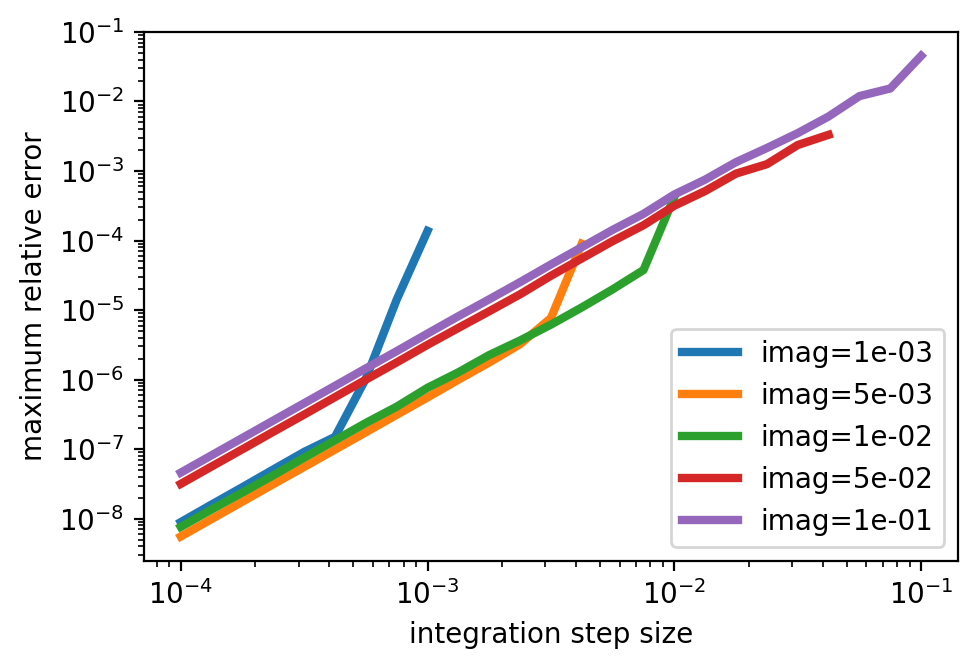

In [45]:
computed_values = np.load('testing_examples\\tables\\integration\\deflection_step_vals.npy')

fig, ax = plt.subplots(figsize=(5, 3.5))

for i, defl in enumerate(deflecs):
    val = computed_values[i, :]
    err = np.abs((val - true_block) / true_block)
    ax.loglog(steps, np.max(err, axis=(-1, -2)), linewidth=3, label=f'imag={defl:1.0e}')

ax.set(xlabel="integration step size", ylabel="maximum relative error")
plt.legend(), plt.tight_layout()
plt.show()

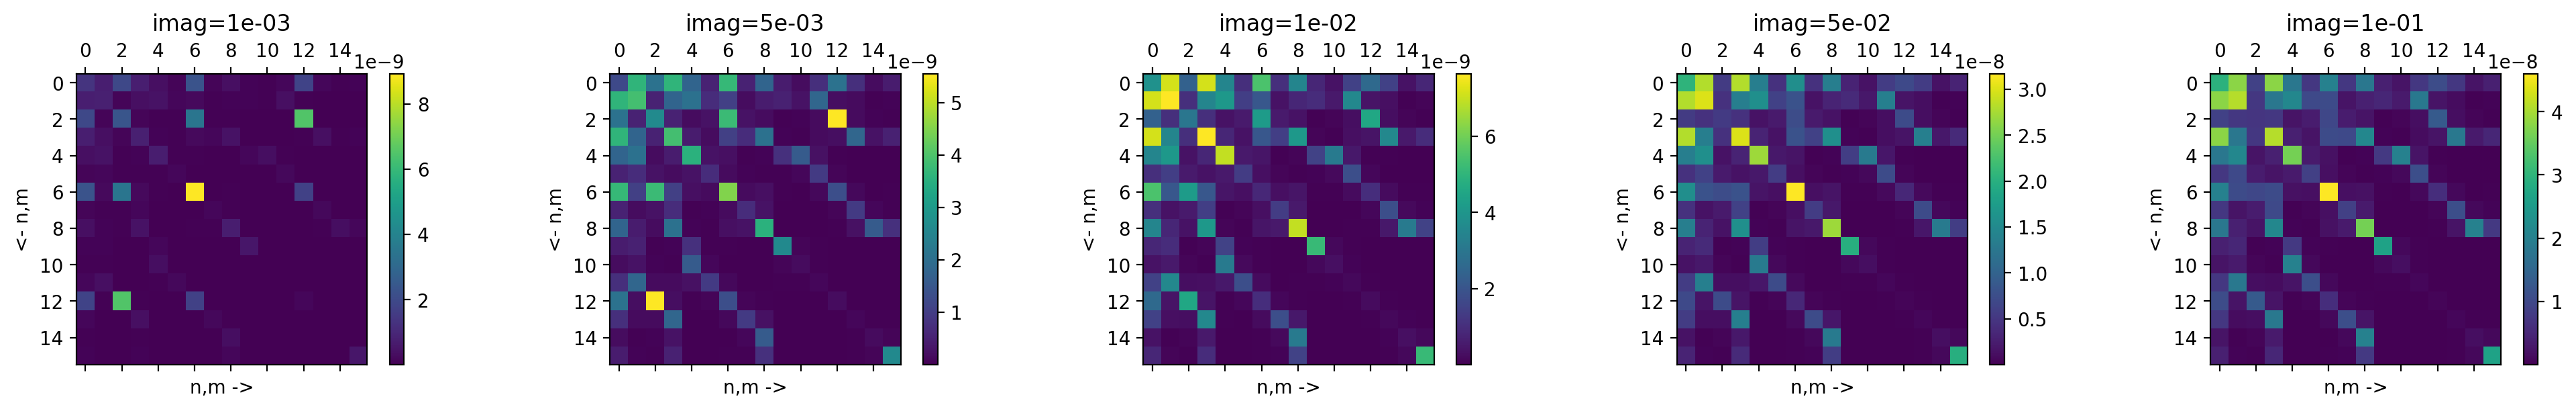

In [46]:
fig, ax = plt.subplots(1, len(deflecs), figsize=(4*len(deflecs), 3))

val0 = true_block
for i, defl in enumerate(deflecs):
    val = computed_values[i, -1]
    err = np.abs((val - val0) / val0)
    im = ax[i].matshow(err)
    plt.colorbar(im, ax=ax[i])
    ax[i].set(ylabel='<- n,m', xlabel='n,m ->', title=f'imag={defl:.0e}')
plt.tight_layout()

### physical: height

In [47]:
n_max = 3

#### height vs kmax

In [48]:
k = 1
distance = 1 / k

In [49]:
deflection = 1e-2
step = 1e-2

finishes = np.array([3, 5, 10, 20, 50, 100, 200, 500])
heights = np.array([1e-2, 1e-1, 5e-1, 1, 10])

# computed_errors = np.zeros((heights.shape[0], finishes.shape[0], (n_max+1)**2, (n_max+1)**2), dtype=float)
# for i, height in enumerate(tqdm(heights)):
#     receiver_pos = np.array([distance/2, 0., height])
#     emitter_pos = np.array([-distance/2, 0., height])

#     true_block = substrate_coupling_block(
#         emitter_pos=emitter_pos, receiver_pos=receiver_pos,
#         k=k, order=n_max 
#     )
    
#     for j, fin in enumerate(finishes):

#         k_par = k_contour(
#             imag_deflection=deflection,
#             step=step,
#             finish=fin,
#         ) * k
        
#         k_z = np.emath.sqrt(k ** 2 - k_par ** 2)
#         legs = mths.legendres_table(k_z / k, n_max=n_max)

#         coupling_block = substrate_coupling_block_integrate(
#             receiver_pos=receiver_pos, 
#             emitter_pos=emitter_pos,
#             k=k, order=n_max,
#             k_parallel=k_par,
#             legendres=legs,
#             medium=med
#         )
        
#         computed_errors[i, j] = abs((coupling_block - true_block) / true_block)
# np.save('.\\testing_examples\\tables\\integration\\height_finish_errs', computed_errors)

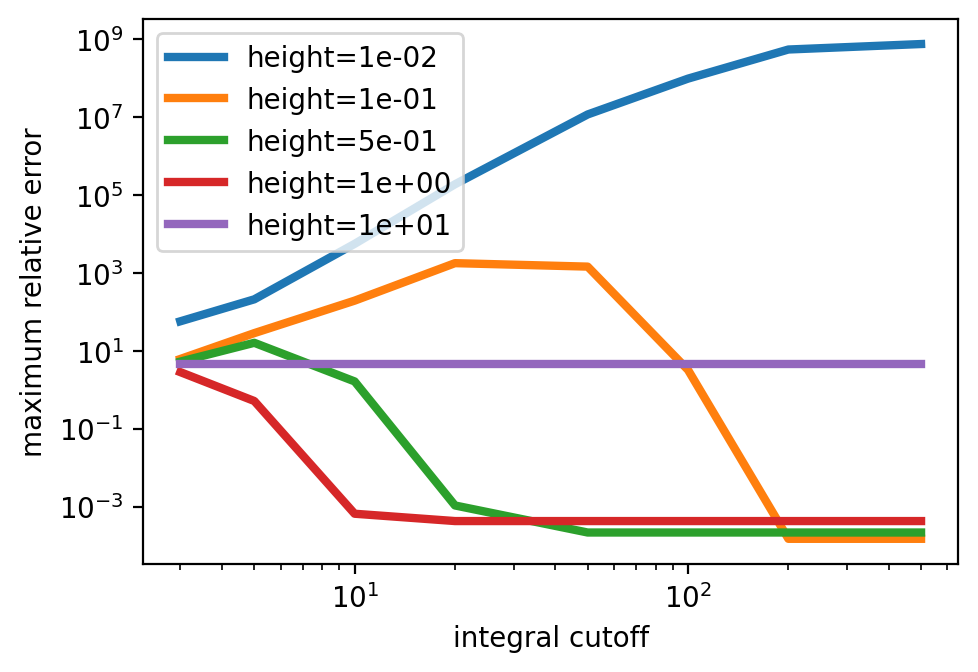

In [50]:
computed_errors = np.load('testing_examples\\tables\\integration\\height_finish_errs.npy')

fig, ax = plt.subplots(figsize=(5, 3.5))

for i, height in enumerate(heights):
    err = np.max(computed_errors[i, :], axis=(-1, -2))
    ax.loglog(finishes, err, linewidth=3, label=f'height={height:.0e}')

ax.set(xlabel="integral cutoff", ylabel="maximum relative error")
plt.legend(), plt.tight_layout()
plt.show()

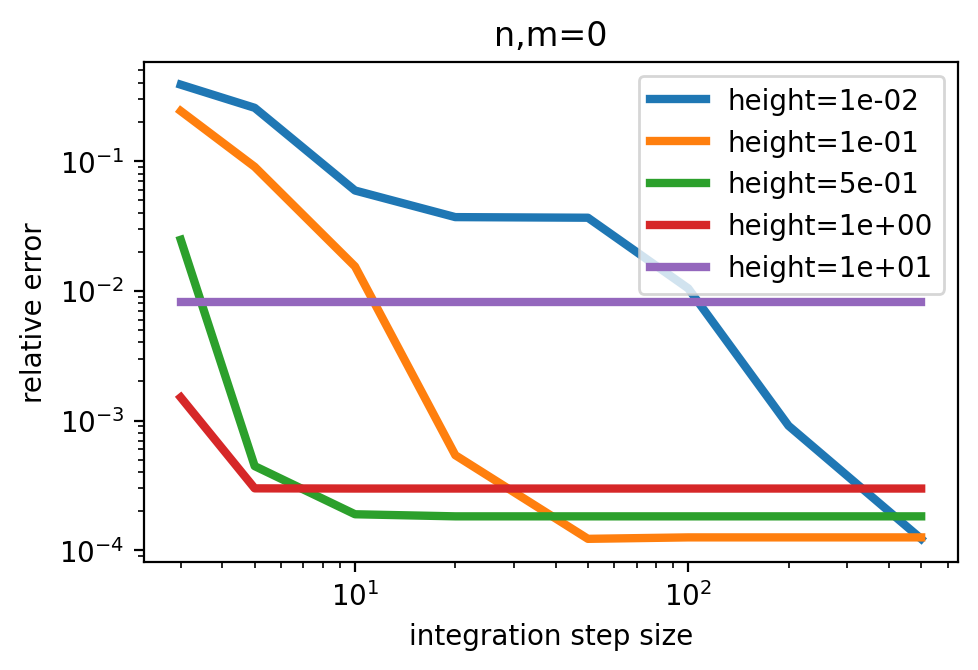

In [51]:
n1, m1, n2, m2 = 0, 0, 0, 0
el_idx = n1**2 + n1 + m1, n2**2 + n2 + m2

fig, ax = plt.subplots(figsize=(5, 3.5))

for i, height in enumerate(heights):
    err = computed_errors[i, :, *el_idx]
    ax.loglog(finishes, err, linewidth=3, label=f'height={height:.0e}')

ax.set(xlabel="integration step size", ylabel="relative error", title='n,m=0')
plt.legend(), plt.tight_layout()
plt.show()

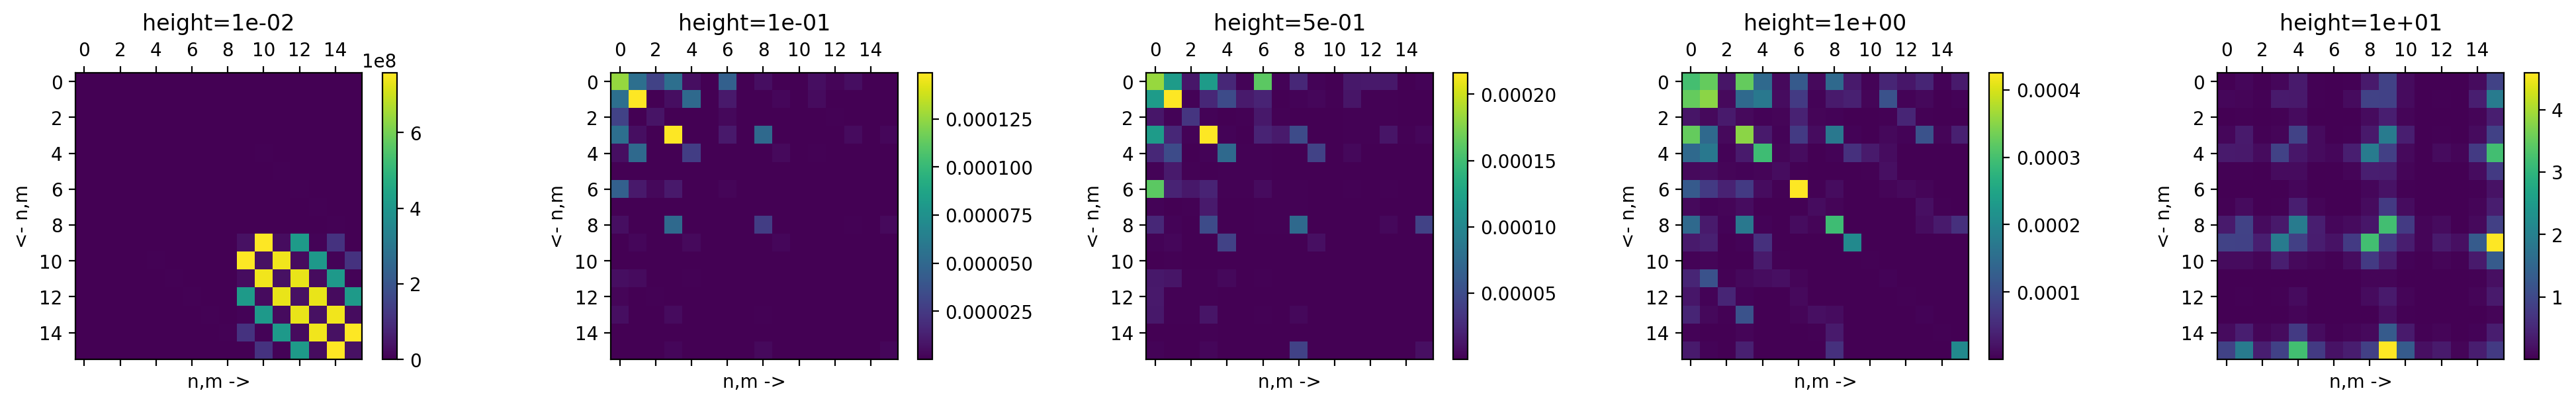

In [52]:
fig, ax = plt.subplots(1, len(heights), figsize=(4*len(heights), 3))

for i, height in enumerate(heights):
    err = computed_errors[i, -1]
    im = ax[i].matshow(err.real)
    plt.colorbar(im, ax=ax[i])
    ax[i].set(ylabel='<- n,m', xlabel='n,m ->', title=f'height={height:.0e}')
plt.tight_layout()

#### height vs step

In [53]:
finish = 50
deflection = 1e-2

steps = np.geomspace(1e-2, 1e-4, 10)
heights = np.array([1e-2, 1e-1, 5e-1, 1, 10])

# computed_errors = np.zeros((heights.shape[0], steps.shape[0], (n_max+1)**2, (n_max+1)**2), dtype=float)
# for i, height in enumerate(tqdm(heights)):
#     receiver_pos = np.array([distance/2, 0., height])
#     emitter_pos = np.array([-distance/2, 0., height])

#     true_block = substrate_coupling_block(
#         emitter_pos=emitter_pos, receiver_pos=receiver_pos,
#         k=k, order=n_max 
#     )
    
#     for j, stp in enumerate(steps):

#         k_par = k_contour(
#             imag_deflection=deflection,
#             step=stp,
#             finish=finish,
#         ) * k
        
#         k_z = np.emath.sqrt(k ** 2 - k_par ** 2)
#         legs = mths.legendres_table(k_z / k, n_max=n_max)

#         coupling_block = substrate_coupling_block_integrate(
#             receiver_pos=receiver_pos, 
#             emitter_pos=emitter_pos,
#             k=k, order=n_max,
#             k_parallel=k_par,
#             legendres=legs,
#             medium=med
#         )
        
#         computed_errors[i, j] = abs((coupling_block - true_block) / true_block)
# np.save('testing_examples\\tables\\integration\\height_step_errs', computed_errors)

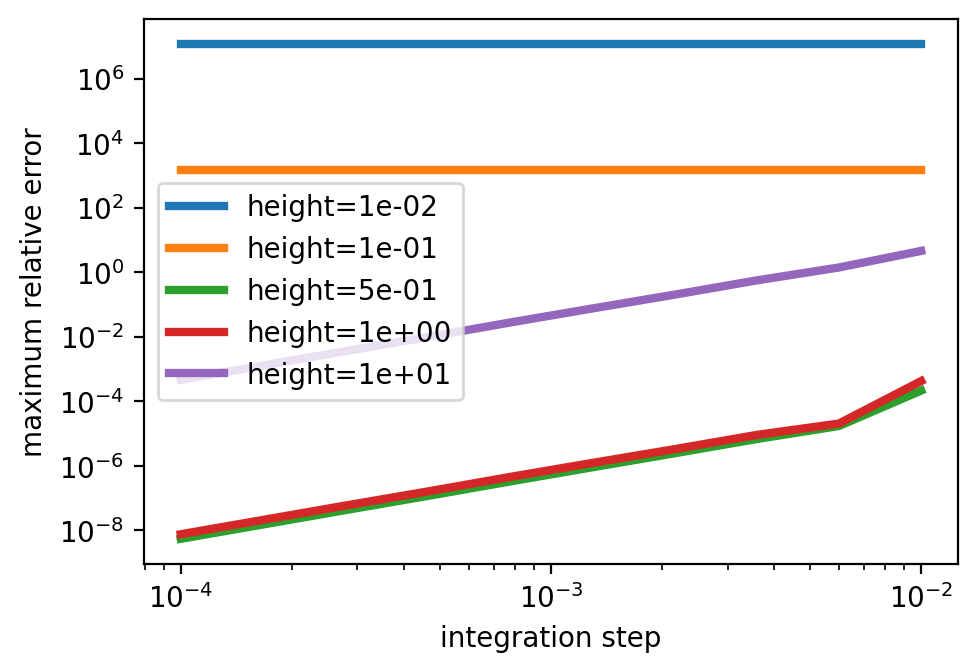

In [54]:
computed_errors = np.load('testing_examples\\tables\\integration\\height_step_errs.npy')

fig, ax = plt.subplots(figsize=(5, 3.5))

for i, height in enumerate(heights):
    err = np.max(computed_errors[i, :], axis=(-1, -2))
    ax.loglog(steps, err, linewidth=3, label=f'height={height:.0e}')

ax.set(xlabel="integration step", ylabel="maximum relative error")
plt.legend(), plt.tight_layout()
plt.show()

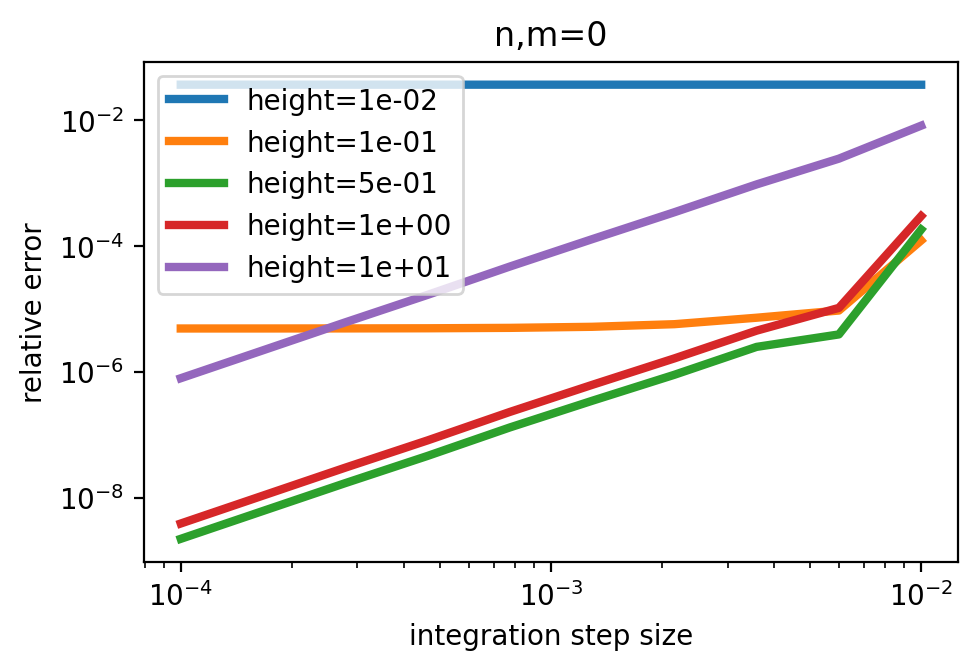

In [55]:
n1, m1, n2, m2 = 0, 0, 0, 0
el_idx = n1**2 + n1 + m1, n2**2 + n2 + m2

fig, ax = plt.subplots(figsize=(5, 3.5))

for i, height in enumerate(heights):
    err = computed_errors[i, :, *el_idx]
    ax.loglog(steps, err, linewidth=3, label=f'height={height:.0e}')

ax.set(xlabel="integration step size", ylabel="relative error", title='n,m=0')
plt.legend(), plt.tight_layout()
plt.show()

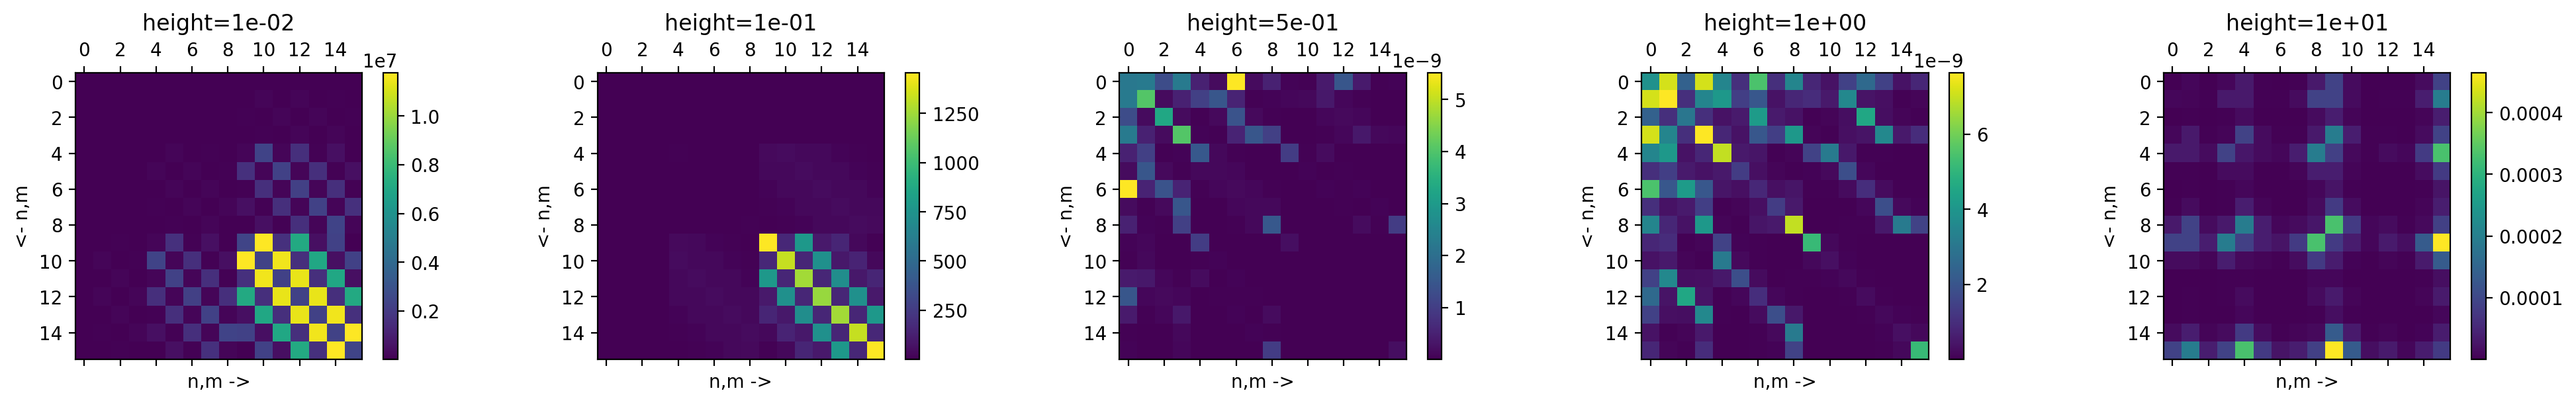

In [56]:
fig, ax = plt.subplots(1, len(heights), figsize=(4*len(heights), 3))

for i, height in enumerate(heights):
    err = computed_errors[i, -1]
    im = ax[i].matshow(err.real)
    plt.colorbar(im, ax=ax[i])
    ax[i].set(ylabel='<- n,m', xlabel='n,m ->', title=f'height={height:.0e}')
plt.tight_layout()

### physical: distance

#### distance vs step

In [57]:
k = 1
height = 1/k

finish = 20
deflection = 1e-2
steps = np.geomspace(1e-2, 1e-4, 15)
distances = np.array([1e-2, 1e-1, 5e-1, 1, 5, 10, 100])

# computed_errors = np.zeros((distances.shape[0], steps.shape[0], (n_max+1)**2, (n_max+1)**2), dtype=float)
# for i, dist in enumerate(tqdm(distances)):
#     receiver_pos = np.array([dist/2, 0., height])
#     emitter_pos = np.array([-dist/2, 0., height])

#     true_block = substrate_coupling_block(
#         emitter_pos=emitter_pos, receiver_pos=receiver_pos,
#         k=k, order=n_max 
#     )
    
#     for j, stp in enumerate(steps):

#         k_par = k_contour(
#             imag_deflection=deflection,
#             step=stp,
#             finish=finish,
#         ) * k
        
#         k_z = np.emath.sqrt(k ** 2 - k_par ** 2)
#         legs = mths.legendres_table(k_z / k, n_max=n_max)

#         coupling_block = substrate_coupling_block_integrate(
#             receiver_pos=receiver_pos, 
#             emitter_pos=emitter_pos,
#             k=k, order=n_max,
#             k_parallel=k_par,
#             legendres=legs,
#             medium=med
#         )
        
#         computed_errors[i, j] = abs((coupling_block - true_block) / true_block)
# np.save('testing_examples\\tables\\integration\\distance_step_errs', computed_errors)

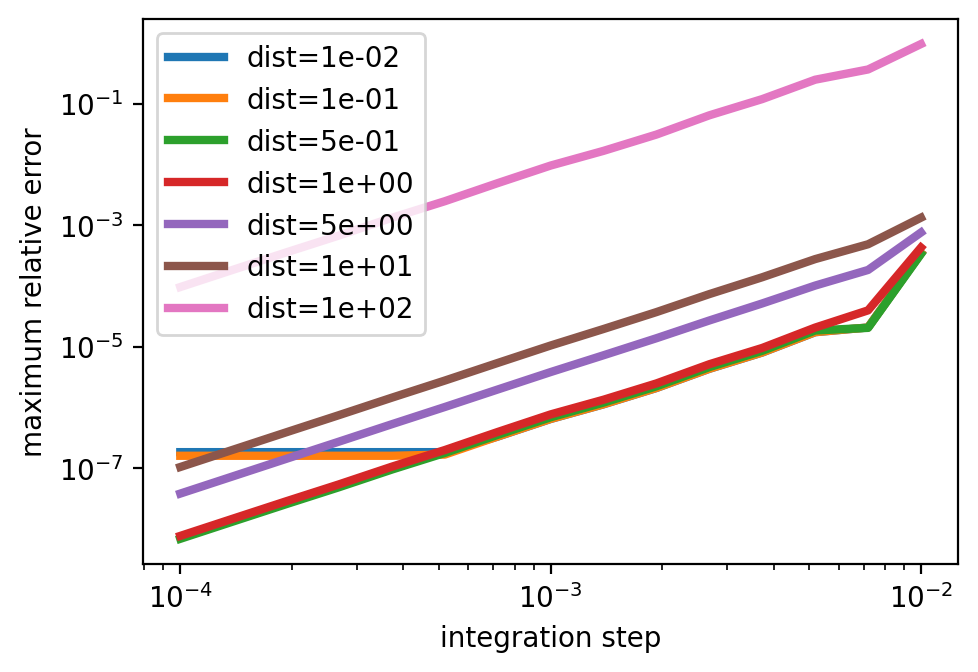

In [58]:
computed_errors = np.load('testing_examples\\tables\\integration\\distance_step_errs.npy')

fig, ax = plt.subplots(figsize=(5, 3.5))

for i, dist in enumerate(distances):
    err = np.max(computed_errors[i, :], axis=(-2, -1))
    ax.loglog(steps, err, linewidth=3, label=f'dist={dist:.0e}')

ax.set(xlabel="integration step", ylabel="maximum relative error")
plt.legend(), plt.tight_layout()
plt.show()

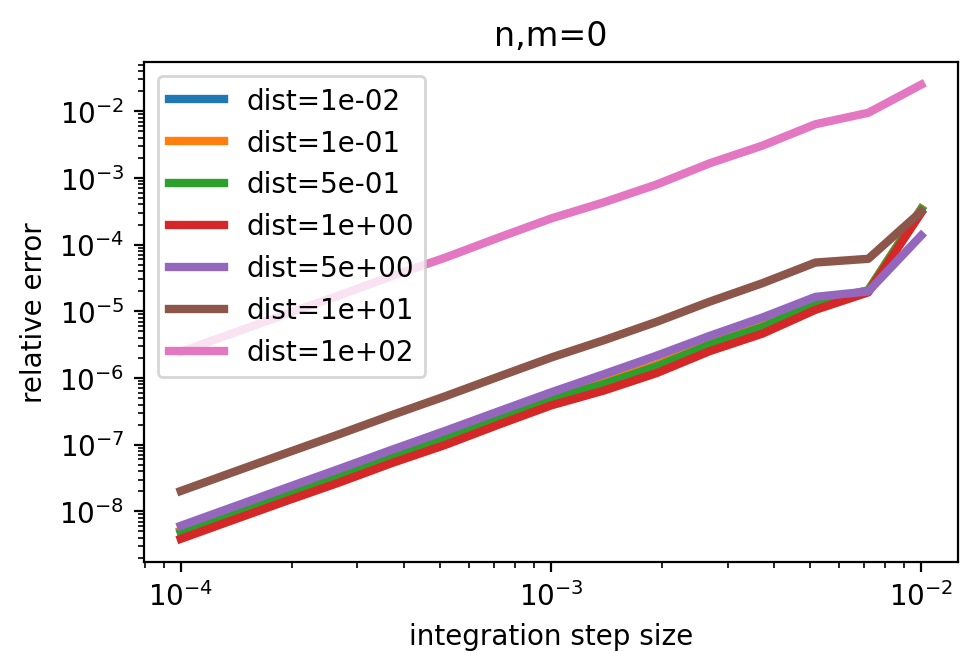

In [59]:
n1, m1, n2, m2 = 0, 0, 0, 0
el_idx = n1**2 + n1 + m1, n2**2 + n2 + m2

fig, ax = plt.subplots(figsize=(5, 3.5))

for i, dist in enumerate(distances):
    err = computed_errors[i, :, *el_idx]
    ax.loglog(steps, err, linewidth=3, label=f'dist={dist:.0e}')

ax.set(xlabel="integration step size", ylabel="relative error", title='n,m=0')
plt.legend(), plt.tight_layout()
plt.show()

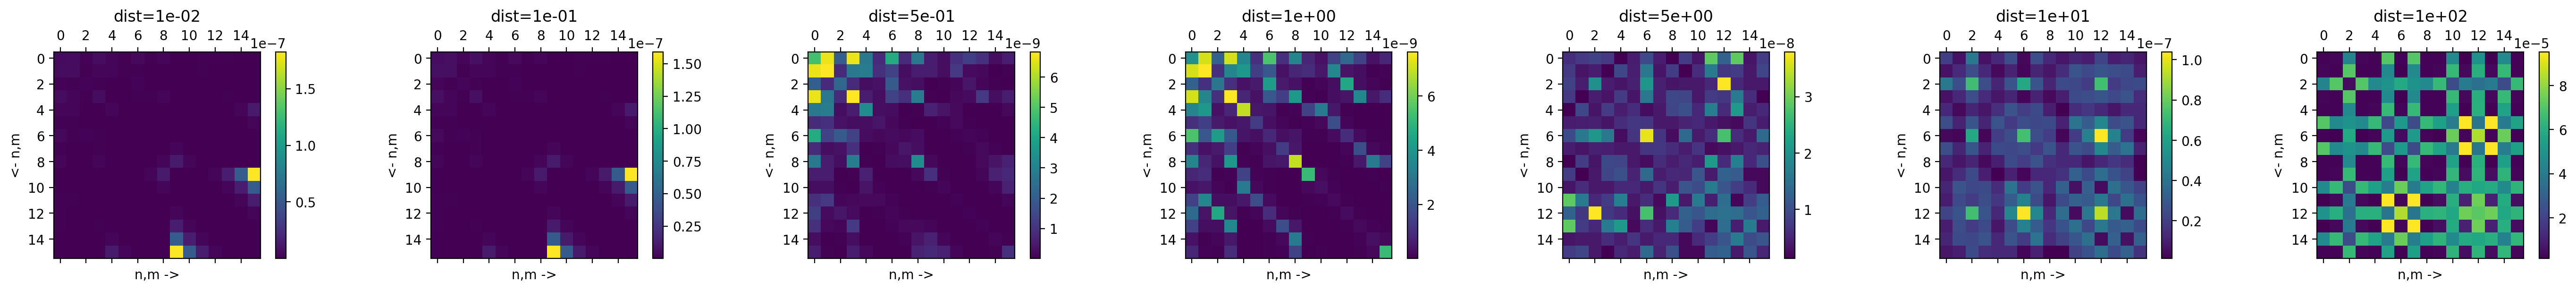

In [60]:
fig, ax = plt.subplots(1, len(distances), figsize=(4*len(distances), 3))

for i, dist in enumerate(distances):
    err = computed_errors[i, -1]
    im = ax[i].matshow(err.real)
    plt.colorbar(im, ax=ax[i])
    ax[i].set(ylabel='<- n,m', xlabel='n,m ->', title=f'dist={dist:.0e}')
plt.tight_layout()

#### distance vs kmax

In [61]:
k = 1
height = 1 / k

deflection = 1e-2
step = 1e-3
finishes = np.array([3, 5, 10, 20, 50, 100, 200, 500])
distances = np.array([1e-2, 1e-1, 5e-1, 1, 5, 10, 100])

# computed_errors = np.zeros((distances.shape[0], finishes.shape[0], (n_max+1)**2, (n_max+1)**2), dtype=float)
# for i, dist in enumerate(tqdm(distances)):
#     receiver_pos = np.array([dist/2, 0., height])
#     emitter_pos = np.array([-dist/2, 0., height])

#     true_block = substrate_coupling_block(
#         emitter_pos=emitter_pos, receiver_pos=receiver_pos,
#         k=k, order=n_max 
#     )
    
#     for j, fin in enumerate(finishes):

#         k_par = k_contour(
#             imag_deflection=deflection,
#             step=step,
#             finish=fin,
#         ) * k
        
#         k_z = np.emath.sqrt(k ** 2 - k_par ** 2)
#         legs = mths.legendres_table(k_z / k, n_max=n_max)

#         coupling_block = substrate_coupling_block_integrate(
#             receiver_pos=receiver_pos, 
#             emitter_pos=emitter_pos,
#             k=k, order=n_max,
#             k_parallel=k_par,
#             legendres=legs,
#             medium=med
#         )
        
#         computed_errors[i, j] = abs((coupling_block - true_block) / true_block)
# np.save('.\\testing_examples\\tables\\integration\\distance_finish_errs', computed_errors)

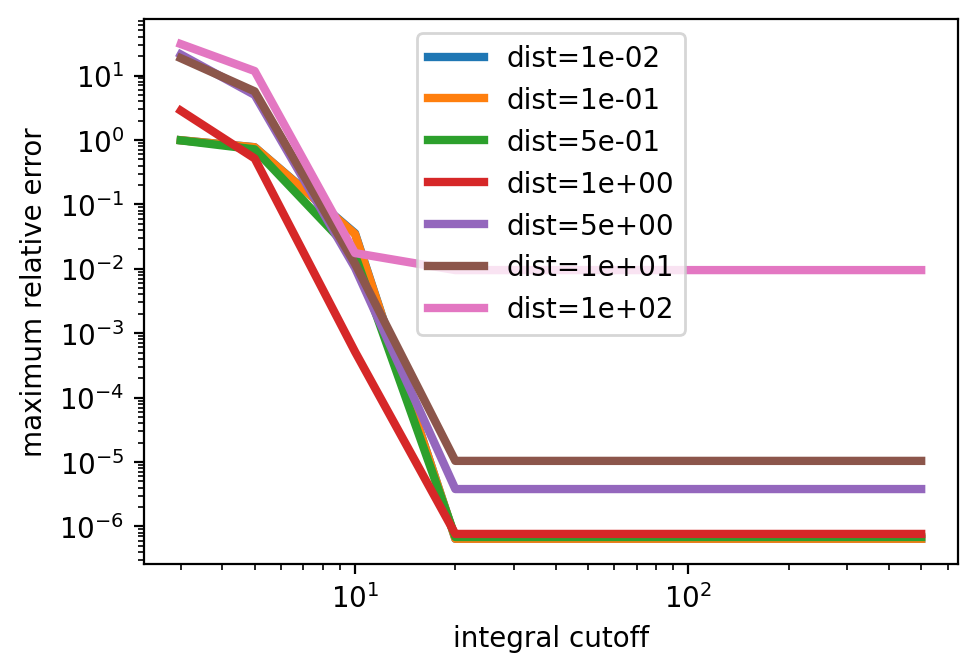

In [62]:
computed_errors = np.load('testing_examples\\tables\\integration\\distance_finish_errs.npy')

fig, ax = plt.subplots(figsize=(5, 3.5))

for i, dist in enumerate(distances):
    err = np.max(computed_errors[i, :], axis=(-1, -2))
    ax.loglog(finishes, err, linewidth=3, label=f'dist={dist:.0e}')

ax.set(xlabel="integral cutoff", ylabel="maximum relative error")
plt.legend(), plt.tight_layout()
plt.show()

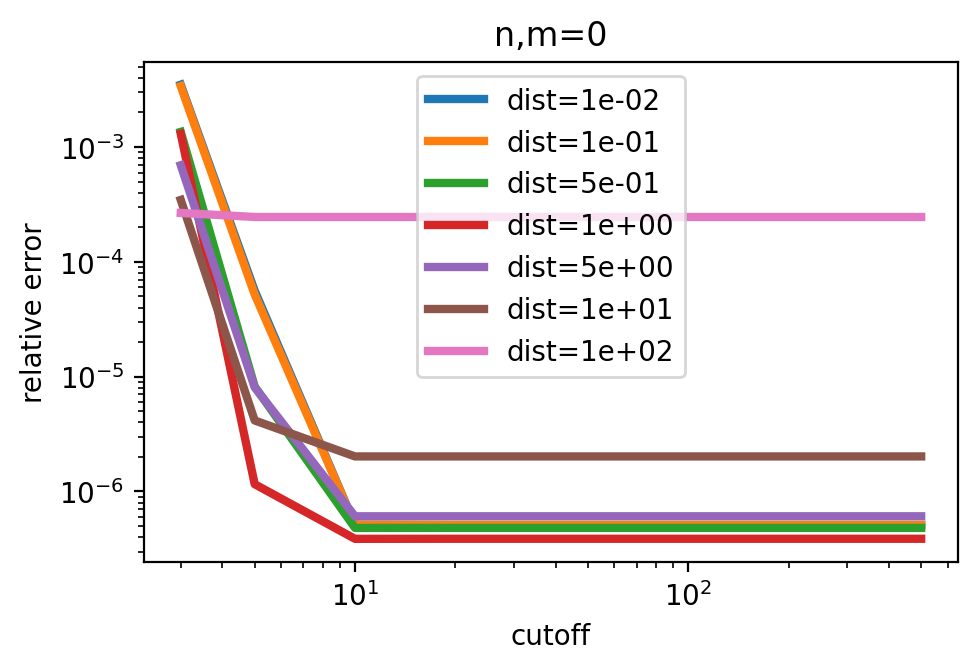

In [63]:
n1, m1, n2, m2 = 0, 0, 0, 0
el_idx = n1**2 + n1 + m1, n2**2 + n2 + m2

fig, ax = plt.subplots(figsize=(5, 3.5))

for i, dist in enumerate(distances):
    err = computed_errors[i, :, *el_idx]
    ax.loglog(finishes, err, linewidth=3, label=f'dist={dist:.0e}')

ax.set(xlabel="cutoff", ylabel="relative error", title='n,m=0')
plt.legend(), plt.tight_layout()
plt.show()

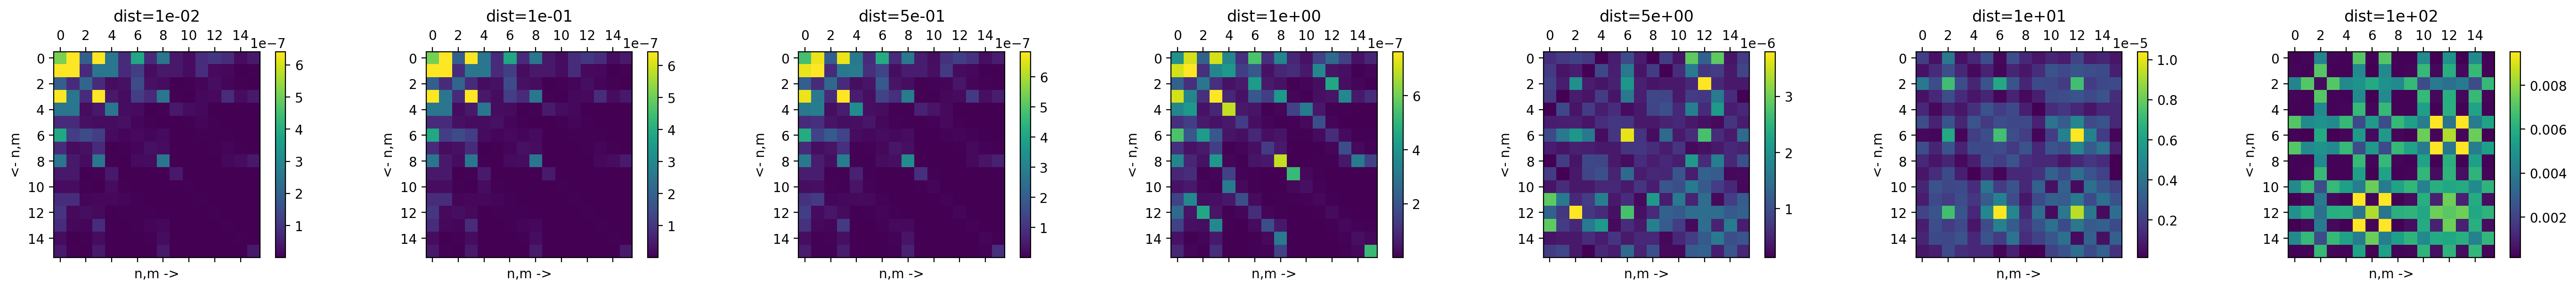

In [64]:
fig, ax = plt.subplots(1, len(distances), figsize=(4*len(distances), 3))

for i, dist in enumerate(distances):
    err = computed_errors[i, -1]
    im = ax[i].matshow(err.real)
    plt.colorbar(im, ax=ax[i])
    ax[i].set(ylabel='<- n,m', xlabel='n,m ->', title=f'dist={dist:.0e}')
plt.tight_layout()